In [1]:
!pwd

/Users/bulat/Documents/datenspende_IMPUTE_sex


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('13Aug_1222.csv', index_col=False) # all users WITH salutation data
# df_null=pd.read_csv('13Aug_1230.csv', index_col=False) # all users WITHOUT salutation data

In [4]:
df[df.notna().all(axis=1)] # we have 6745 complete cases

,user_id,salutation,birth_date,weight,height,source
25,250,20,1975.0,70.0,170.0,6.0
62,363,10,1955.0,75.0,150.0,6.0
77,426,20,1990.0,85.0,180.0,6.0
93,494,20,1970.0,110.0,185.0,6.0
130,647,20,1975.0,75.0,175.0,6.0
...,...,...,...,...,...,...
286673,1244233,20,1960.0,85.0,185.0,4.0
287453,1245093,10,1975.0,90.0,175.0,6.0
288456,1246227,20,1960.0,85.0,170.0,6.0
290554,1248658,20,1990.0,70.0,175.0,6.0


### Daily data
lets get Complete Cases for users with non-null source-salutation-birthdate-weight-age (n=6745). Then we'll get daily vals for these ids from vitaldata


In [5]:
df_cc=df.loc[df.notna().all(axis=1), :]
df_data=pd.read_csv('13Aug_1338.csv', index_col=False) # daily vals

In [6]:
l_cc=df_cc.user_id.unique().tolist() # users with CC data
l_data=df_data.user_id.unique().tolist() # user with daily vals
l_remove1=[x for x in l_cc if x not in l_data] # CC users who DO NOT have daily vals. We cant use them
l_remove2=[x for x in l_data if x not in l_cc] # CC users who DO NOT have daily vals. We cant use them

print(f'num users with Complete Case records, but absent from daily data: {len(l_remove1)}\nQ: are they in epoch values?\nA: spot checking clickhouse, doesnt look like that\n')
print(f'num users with Daily vals, but absent from CC data: {len(l_remove2)}\n')

# lets print num and save those IDs
for l, name in zip( [l_remove1, l_remove2, l_data, l_cc], ['id_inCC_notinPG.txt', 'id_inPG_notinCC.txt', 'id_in_PG.txt', 'id_CC.txt']):
    print(f'{name}:{len(l)}')
#    if len(l)>0:
#        with open(name, 'w') as f:
#            f.write(', '.join(map(str, l)))

num users with Complete Case records, but absent from daily data: 104
Q: are they in epoch values?
A: spot checking clickhouse, doesnt look like that

num users with Daily vals, but absent from CC data: 0

id_inCC_notinPG.txt:104
id_inPG_notinCC.txt:0
id_in_PG.txt:6641
id_CC.txt:6745


In [7]:
# Lets take thos who have daily vals, so remove ids (n=104) without dailys
df_cc = df_cc.loc[ df_cc.user_id.isin(l_data), :] 

### We need to be careful about users that have several sources, ie we cannot just remove users that have unique(source)>1

In [8]:
df_data.groupby('user_id').filter(lambda g: g['source'].nunique()>1)['user_id'].nunique() # 1654 users have several sources

1654

In [9]:
df_data.groupby('user_id').filter(lambda g: g['source'].nunique()==1)['user_id'].nunique() # 4987 users have several sources

4987

In [10]:
4987+1654

6641

#### lets just look at people with a single source

In [11]:
l_usource = df_data.groupby('user_id')\
    .filter(lambda g: g['source']\
            .nunique()==1)['user_id']\
                .unique().tolist()

In [12]:
df_cohort = df_cc.loc[df_cc.user_id.isin(l_usource), :] # n=4987
df_vitals=df_data.loc[df_data.user_id.isin(l_usource), :] # n=4987

In [13]:
set(df_vitals.groupby('user_id')['source'].nunique().values)

{np.int64(1)}

In [14]:
df_cohort.groupby(['source', 'salutation']).size() # we have to remove sources 46&48

source  salutation
2.0     10             166
        20             110
3.0     10             106
        20             222
4.0     10              40
        20              59
6.0     10            1340
        20            2783
7.0     10              13
        20              26
        30               1
9.0     10               5
        20              18
13.0    10              11
        20              52
19.0    10               1
46.0    10               7
        20              16
48.0    10               1
        20              10
dtype: int64

In [15]:
l_remove3=df_cohort[df_cohort.source.isin([46,48])]['user_id'].tolist()

df_cohort = df_cohort.loc[~df_cohort.user_id.isin(l_remove3), :]
df_vitals=df_vitals.loc[~df_vitals.user_id.isin(l_remove3), :]

print(f'num users in cohort: {len(df_cohort)}\nnum users with viatls: {len(df_vitals.user_id.unique())}')

num users in cohort: 4953
num users with viatls: 4953


In [16]:
# sanity check

l_cc=df_cohort.user_id.unique().tolist()
l_data=df_vitals.user_id.unique().tolist()

assert len([x for x in l_data if x not in l_cc])==0 # should be 0, ie no users with daily vals are absent from CC 
assert len([x for x in l_data if x in l_cc]) == len(l_cc) # all users with data are in CC
assert all(df_cc.user_id.unique() == df_data.user_id.unique()) # all users should match
print('OK')

OK


In [17]:
# map num values to strings
d_salutation={10: 'F', 20: 'M', 30: 'IDK'}
d_source={2.0: 'Fitbit', 
                                     3.0: 'Garmin',
                                     4.0: 'Polar',
                                     6.0: 'Apple',
                                     7.0: 'Samsung',
                                     9.0: 'Nokia',
                                     13.0: 'GoogleFit',
                                     19.0: 'Oura'
                                     }

df_cohort['salutation']=df_cohort['salutation'].map(d_salutation)
df_cohort['source']=df_cohort['source'].map(d_source)

df_vitals['source']=df_vitals['source'].map(d_source)
print(f'num users in cohort: {len(df_cohort)}\nnum users with vitals: {len(df_vitals.user_id.unique())}')

num users in cohort: 4953
num users with vitals: 4953


In [18]:
df_cohort

,user_id,salutation,birth_date,weight,height,source
25,250,M,1975.0,70.0,170.0,Apple
62,363,F,1955.0,75.0,150.0,Apple
77,426,M,1990.0,85.0,180.0,Apple
93,494,M,1970.0,110.0,185.0,Apple
149,799,M,1970.0,120.0,190.0,Apple
...,...,...,...,...,...,...
282365,1239385,F,1975.0,60.0,175.0,Polar
282543,1239583,F,1970.0,65.0,165.0,Polar
285222,1242624,F,1980.0,80.0,170.0,Polar
286552,1244097,M,1970.0,95.0,185.0,Polar


In [19]:
temp=df_cohort\
    .groupby(['source', 'salutation'])\
        ['user_id'].size().reset_index()

temp['pct'] = round(100*temp['user_id'] / temp.groupby('source')['user_id'].transform('sum'), 1)
temp # looks like Fitbit has more F than M. We also need to remove Oura (n=1) and a single (remaining IDK) from Samsung

,source,salutation,user_id,pct
0,Apple,F,1340,32.5
1,Apple,M,2783,67.5
2,Fitbit,F,166,60.1
3,Fitbit,M,110,39.9
4,Garmin,F,106,32.3
5,Garmin,M,222,67.7
6,GoogleFit,F,11,17.5
7,GoogleFit,M,52,82.5
8,Nokia,F,5,21.7
9,Nokia,M,18,78.3


In [20]:
l_remove4=(
    df_cohort[df_cohort.source=='Oura']['user_id'].values.tolist()+\
    df_cohort[df_cohort.salutation=='IDK']['user_id'].values.tolist()
    )

df_cohort = df_cohort.loc[~df_cohort.user_id.isin(l_remove4), :]
df_vitals=df_vitals.loc[~df_vitals.user_id.isin(l_remove4), :]

print(f'num users in cohort: {len(df_cohort)}\nnum users with viatls: {len(df_vitals.user_id.unique())}')

num users in cohort: 4951
num users with viatls: 4951


In [21]:
temp=df_cohort\
    .groupby(['source', 'salutation'])\
        ['user_id'].size().reset_index()

temp['pct'] = round(100*temp['user_id'] / temp.groupby('source')['user_id'].transform('sum'), 1)
temp # looks like Fitbit has more F than M. We also need to remove Oura (n=1) and a single (remaining IDK) from Samsung

,source,salutation,user_id,pct
0,Apple,F,1340,32.5
1,Apple,M,2783,67.5
2,Fitbit,F,166,60.1
3,Fitbit,M,110,39.9
4,Garmin,F,106,32.3
5,Garmin,M,222,67.7
6,GoogleFit,F,11,17.5
7,GoogleFit,M,52,82.5
8,Nokia,F,5,21.7
9,Nokia,M,18,78.3


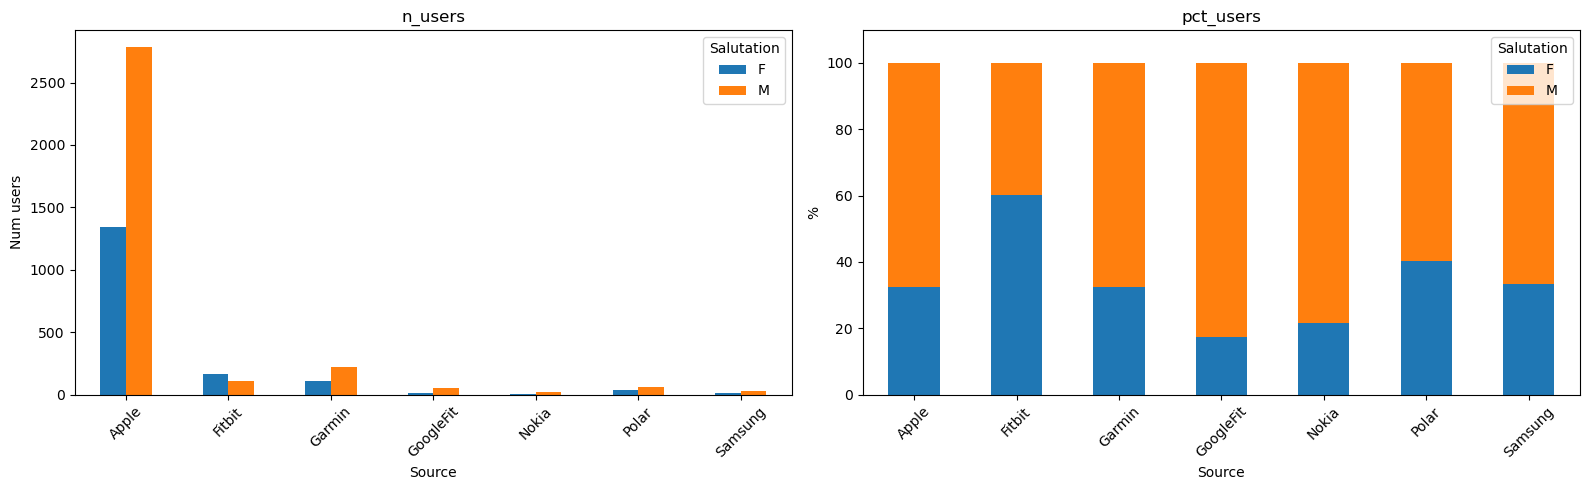

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


temp.pivot(index='source', columns='salutation', values='user_id')\
    .plot(kind='bar', ax=axes[0], ylabel='Num users', xlabel='Source', rot=45)

temp.pivot(index='source', columns='salutation', values='pct')\
    .plot(kind='bar', stacked=True, ax=axes[1], ylabel='%', xlabel='Source', rot=45)

axes[0].legend(title='Salutation')
axes[1].legend(title='Salutation')
axes[0].set_title('n_users')
axes[1].set_title('pct_users')
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.show()


In [23]:
d_type={9:'steps', 43:'sleep_duration', 52:'sleep_onset', 53:'sleep_offset', 65:'RHR', 66:'sleep_HR'}
df_vitals['type']=df_vitals['type'].map(d_type)

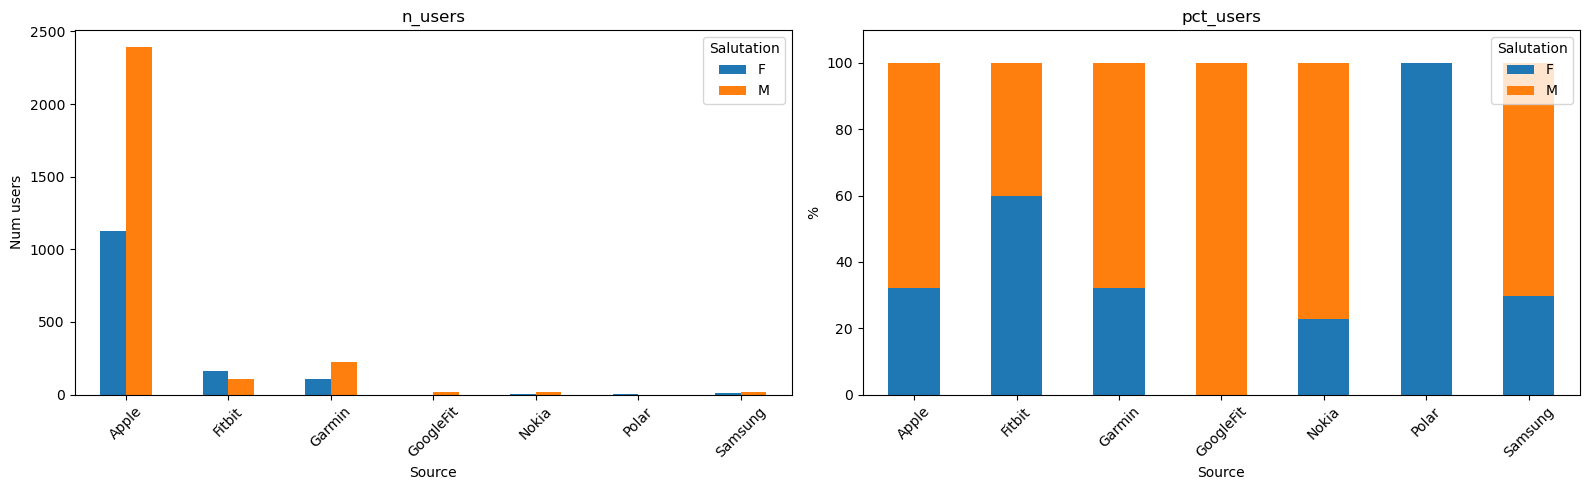

In [24]:
l_temp=df_vitals[df_vitals.type=='RHR'].user_id.unique().tolist()
temp=df_cohort[df_cohort.user_id.isin(l_temp)]\
    .groupby(['source', 'salutation'])\
        ['user_id'].size().reset_index()

temp['pct'] = round(100*temp['user_id'] / temp.groupby('source')['user_id'].transform('sum'), 1)
temp # looks like Fitbit has more F than M. We also need to remove Oura (n=1) and a single (remaining IDK) from Samsung

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


temp.pivot(index='source', columns='salutation', values='user_id')\
    .plot(kind='bar', ax=axes[0], ylabel='Num users', xlabel='Source', rot=45)

temp.pivot(index='source', columns='salutation', values='pct')\
    .plot(kind='bar', stacked=True, ax=axes[1], ylabel='%', xlabel='Source', rot=45)

axes[0].legend(title='Salutation')
axes[1].legend(title='Salutation')
axes[0].set_title('n_users')
axes[1].set_title('pct_users')
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.show()


### Further cleaning based on num available values per source

In [25]:
temp # looks like for now we gonna take only APPLE / FITBIT / GARMIN

,source,salutation,user_id,pct
0,Apple,F,1124,32.0
1,Apple,M,2391,68.0
2,Fitbit,F,161,59.9
3,Fitbit,M,108,40.1
4,Garmin,F,104,32.0
5,Garmin,M,221,68.0
6,GoogleFit,M,18,100.0
7,Nokia,F,5,22.7
8,Nokia,M,17,77.3
9,Polar,F,1,100.0


In [26]:
l_keep=df_cohort[df_cohort.source.isin(['Apple', 'Fitbit', 'Garmin'])]['user_id'].tolist()

df_cohort = df_cohort.loc[df_cohort.user_id.isin(l_keep), :]
df_vitals=df_vitals.loc[df_vitals.user_id.isin(l_keep), :]

print(f'num users in cohort: {len(df_cohort)}\nnum users with vitals: {len(df_vitals.user_id.unique())}')

num users in cohort: 4727
num users with vitals: 4727


In [27]:
# Save users (n=4727) that we want to 
pd.DataFrame(data=l_keep, columns=['user_id']).to_csv('user_id_forClickhouse.csv', index=False)

In [28]:
# a clickhouse query. Workaround since i dont have access to create temp tables in clickhouse, so i gotta print the query
s_user_id = ",\n".join(map(str, l_keep))
print(f'select vde.customer, vde.type, vde.`longValue`, vde.`startTimestamp`, vde.`timezoneOffset` from vital_data_epoch vde where vde.customer IN (\n{s_user_id}\n) and vde.type in (3000,3001,3002)')


select vde.customer, vde.type, vde.`longValue`, vde.`startTimestamp`, vde.`timezoneOffset` from vital_data_epoch vde where vde.customer IN (
250,
363,
426,
494,
799,
1114,
1571,
1778,
1965,
2449,
2593,
2633,
2671,
2854,
2867,
3012,
3087,
3308,
3975,
4094,
4117,
4149,
4264,
4369,
4464,
4688,
4703,
4719,
4861,
5617,
5845,
6007,
6140,
6641,
6781,
6823,
7605,
7818,
7846,
7944,
7966,
8110,
8233,
8247,
8352,
8358,
8383,
8546,
8939,
9280,
9292,
9413,
9809,
9895,
10155,
10177,
10570,
10578,
10600,
11338,
11861,
12075,
12163,
12243,
12698,
13154,
13230,
13347,
13454,
13527,
13539,
13645,
13697,
13720,
13768,
13783,
14256,
14667,
14729,
15098,
15109,
15390,
15485,
15497,
16152,
16215,
16554,
16629,
16735,
16812,
16950,
16989,
17294,
17451,
17465,
17509,
18093,
18259,
18455,
18500,
18900,
18950,
19055,
19209,
19213,
19219,
19598,
20183,
20213,
20295,
20373,
20449,
21018,
21067,
21149,
21193,
21315,
21339,
21861,
22018,
22171,
22213,
22415,
22428,
22455,
22545,
22555,
22605,
22766,
22810,
22866,
2

In [29]:
l_keep[:3]

[250, 363, 426]

In [30]:
df_data[df_data.user_id==677].sort_values(axis='index', by='date').head(n=30) # user 677 has several (n=3) sources

,user_id,date,type,value,source
16210,677,2020-04-12,43,418,2
16578,677,2020-04-12,65,80,6
16206,677,2020-04-12,66,80,2
18592,677,2020-04-12,9,5924,9
16208,677,2020-04-12,53,1586682180,2
16207,677,2020-04-12,65,80,2
16209,677,2020-04-12,52,1586654190,2
23031,677,2020-04-12,9,2765,2
16579,677,2020-04-13,65,81,6
18593,677,2020-04-13,9,12892,9
